# Batch Normalization vs. Plain CNN: Visualizing Gradient Flow

Batch Normalization often gets credit for faster convergence, but the mechanics can feel abstract. This notebook builds two nearly identical CNNs—one with BatchNorm, one without—and visualizes how their activations and gradients behave during training.

## Learning Goals
- Train paired CNNs on CIFAR-10 with and without BatchNorm using a consistent setup.
- Capture per-layer activation statistics and gradient norms throughout training.
- Visualize how BatchNorm stabilizes activation distributions and gradients over epochs.

## 1. Imports, Seeds, and Device Check
We gather the libraries used for training, data handling, and plotting. The cell prints the key versions and confirms the device so results are reproducible.

In [1]:
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

sns.set_theme(context='talk', style='whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SEED = 12
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'torch version: {torch.__version__}')
print(f'torchvision version: {torchvision.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

torch version: 2.8.0
torchvision version: 0.23.0
Using device: cpu


## 2. Build the CIFAR-10 Data Pipeline
We downsample CIFAR-10 to a manageable subset, apply simple tensor conversion and scaling, and prepare loaders for training, validation, and a fixed probe batch used to inspect activations.

In [2]:
DATA_DIR = Path('cifar_data')
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=transform)
val_dataset = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=transform)

TRAIN_SIZE = 5000
VAL_SIZE = 1000
indices = torch.randperm(len(train_dataset))
train_subset = Subset(train_dataset, indices[:TRAIN_SIZE])
val_subset = Subset(val_dataset, torch.arange(VAL_SIZE))

BATCH_SIZE = 128
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
probe_loader = DataLoader(val_subset, batch_size=64, shuffle=False)
probe_inputs, probe_targets = next(iter(probe_loader))
probe_inputs, probe_targets = probe_inputs.to(device), probe_targets.to(device)

print(f'Train batches: {len(train_loader)}, validation batches: {len(val_loader)}')

  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 65.5k/170M [00:00<05:13, 543kB/s]

  0%|          | 229k/170M [00:00<03:10, 895kB/s] 

  0%|          | 786k/170M [00:00<01:04, 2.65MB/s]

  1%|          | 1.80M/170M [00:00<00:32, 5.14MB/s]

...

 96%|█████████▌| 164M/170M [00:05<00:00, 23.0MB/s]

 97%|█████████▋| 166M/170M [00:06<00:00, 23.0MB/s]

 99%|█████████▊| 168M/170M [00:06<00:00, 23.2MB/s]

100%|██████████| 170M/170M [00:06<00:00, 27.5MB/s]

Train batches: 40, validation batches: 8


## 3. Glimpse the Dataset
A quick montage of sample images keeps the classification task in mind while we inspect model internals later.

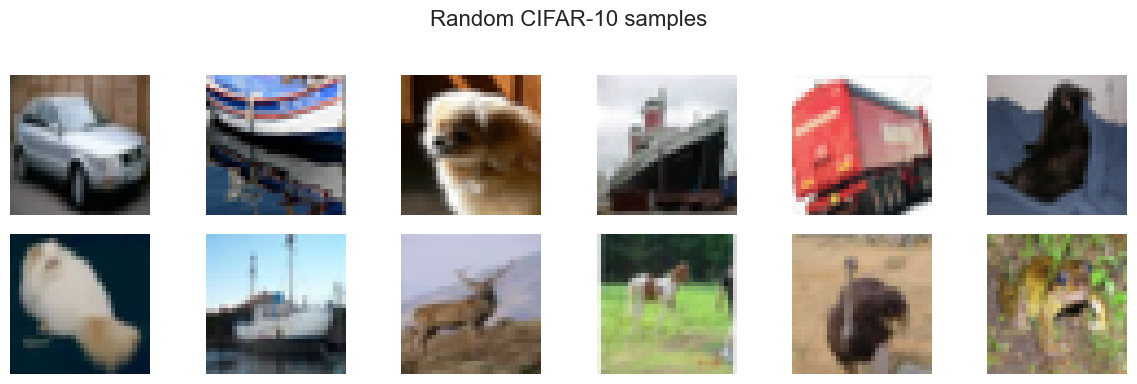

In [3]:
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax in axes.flatten():
    img, label = train_dataset[random.randrange(len(train_dataset))]
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    ax.axis('off')
fig.suptitle('Random CIFAR-10 samples', fontsize=16)
plt.tight_layout()
plt.show()

## 4. Define Paired CNN Architectures
Both models share the same layout (two conv blocks and two linear layers). The BatchNorm variant inserts normalization after each learnable layer. The forward method can optionally return intermediate activations for analysis.

In [4]:
class SmallConvNet(nn.Module):
    def __init__(self, use_batchnorm: bool = False):
        super().__init__()
        self.use_batchnorm = use_batchnorm

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else nn.Identity()
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else nn.Identity()

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.bn3 = nn.BatchNorm1d(128) if use_batchnorm else nn.Identity()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x, return_activations: bool = False):
        activations = {}

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        activations['conv1'] = x
        x = F.max_pool2d(x, kernel_size=2)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        activations['conv2'] = x
        x = F.max_pool2d(x, kernel_size=2)

        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        x = self.bn3(x)
        x = F.relu(x)
        activations['fc1'] = x

        logits = self.fc2(x)
        activations['fc2'] = logits

        if return_activations:
            return logits, activations
        return logits

## 5. Training and Instrumentation Utilities
Helper routines train a model, evaluate on the validation split, capture activation statistics from a fixed probe batch, and summarize gradient norms per layer.

In [5]:
EPOCHS = 5
LEARNING_RATE = 1e-3
TRACKED_LAYERS = ['conv1', 'conv2', 'fc1', 'fc2']
criterion = nn.CrossEntropyLoss()

metrics_rows = []
activation_records = []
activation_samples = []
gradient_records = []


def evaluate(model, loader):
    was_training = model.training
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits = model(inputs)
            loss = criterion(logits, targets)
            total_loss += loss.item() * inputs.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == targets).sum().item()
            total_examples += inputs.size(0)
    model.train(was_training)
    return total_loss / total_examples, total_correct / total_examples


def capture_activations(model, model_name: str, epoch: int, sample_count: int = 4000):
    was_training = model.training
    model.eval()
    with torch.no_grad():
        logits, acts = model(probe_inputs, return_activations=True)
    for layer_name, tensor in acts.items():
        data = tensor.detach().reshape(-1).cpu()
        mean = data.mean().item()
        std = data.std(unbiased=False).item()
        activation_records.append({
            'model': model_name,
            'epoch': epoch,
            'layer': layer_name,
            'mean': mean,
            'std': std,
        })
        if data.numel() > sample_count:
            idx = torch.randperm(data.numel())[:sample_count]
            sample = data[idx]
        else:
            sample = data
        activation_samples.append({
            'model': model_name,
            'epoch': epoch,
            'layer': layer_name,
            'values': sample.numpy(),
        })
    model.train(was_training)


def train_model(model_name: str, model: nn.Module):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_examples = 0
        batch_count = 0
        grad_sums = {layer: 0.0 for layer in TRACKED_LAYERS}

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(inputs)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * inputs.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == targets).sum().item()
            total_examples += inputs.size(0)
            batch_count += 1

            for layer_name, module in model.named_modules():
                if layer_name in TRACKED_LAYERS and hasattr(module, 'weight') and module.weight.grad is not None:
                    grad_sums[layer_name] += module.weight.grad.detach().norm().item()

        train_loss = total_loss / total_examples
        train_acc = total_correct / total_examples
        val_loss, val_acc = evaluate(model, val_loader)

        metrics_rows.extend([
            {'model': model_name, 'epoch': epoch, 'split': 'train', 'metric': 'loss', 'value': train_loss},
            {'model': model_name, 'epoch': epoch, 'split': 'train', 'metric': 'accuracy', 'value': train_acc},
            {'model': model_name, 'epoch': epoch, 'split': 'val', 'metric': 'loss', 'value': val_loss},
            {'model': model_name, 'epoch': epoch, 'split': 'val', 'metric': 'accuracy', 'value': val_acc},
        ])

        for layer_name in TRACKED_LAYERS:
            gradient_records.append({
                'model': model_name,
                'epoch': epoch,
                'layer': layer_name,
                'grad_norm': grad_sums[layer_name] / max(batch_count, 1),
            })

        capture_activations(model, model_name, epoch)
        print(f"[{model_name}] Epoch {epoch}: train loss {train_loss:.4f}, val acc {val_acc:.3f}")


models = {
    'With BatchNorm': SmallConvNet(use_batchnorm=True),
    'No BatchNorm': SmallConvNet(use_batchnorm=False),
}

## 6. Train Both Models
Running the paired training loops captures metrics, activations, and gradients in the shared tracking structures for later visualization.

In [6]:
for name, model in models.items():
    train_model(name, model)

[With BatchNorm] Epoch 1: train loss 1.6584, val acc 0.211


[With BatchNorm] Epoch 2: train loss 1.2198, val acc 0.451


[With BatchNorm] Epoch 3: train loss 0.9849, val acc 0.543


[With BatchNorm] Epoch 4: train loss 0.7472, val acc 0.539


[With BatchNorm] Epoch 5: train loss 0.5621, val acc 0.530


[No BatchNorm] Epoch 1: train loss 2.1062, val acc 0.351


[No BatchNorm] Epoch 2: train loss 1.7829, val acc 0.382


[No BatchNorm] Epoch 3: train loss 1.6182, val acc 0.439


[No BatchNorm] Epoch 4: train loss 1.5128, val acc 0.442


[No BatchNorm] Epoch 5: train loss 1.4449, val acc 0.440


## 7. Assemble Metrics into DataFrames
We bundle the recorded metrics, activation summaries, and gradient norms into tidy DataFrames that drive the upcoming plots.

In [7]:
metrics_df = pd.DataFrame(metrics_rows)
activation_df = pd.DataFrame(activation_records)
gradient_df = pd.DataFrame(gradient_records)

metrics_df.head()

,model,epoch,split,metric,value
0,With BatchNorm,1,train,loss,1.658391
1,With BatchNorm,1,train,accuracy,0.419800
2,With BatchNorm,1,val,loss,2.165176
3,With BatchNorm,1,val,accuracy,0.211000
4,With BatchNorm,2,train,loss,1.219762


## 8. Training Curves
Loss and accuracy over epochs show the BatchNorm model converging faster and more smoothly than its plain counterpart.

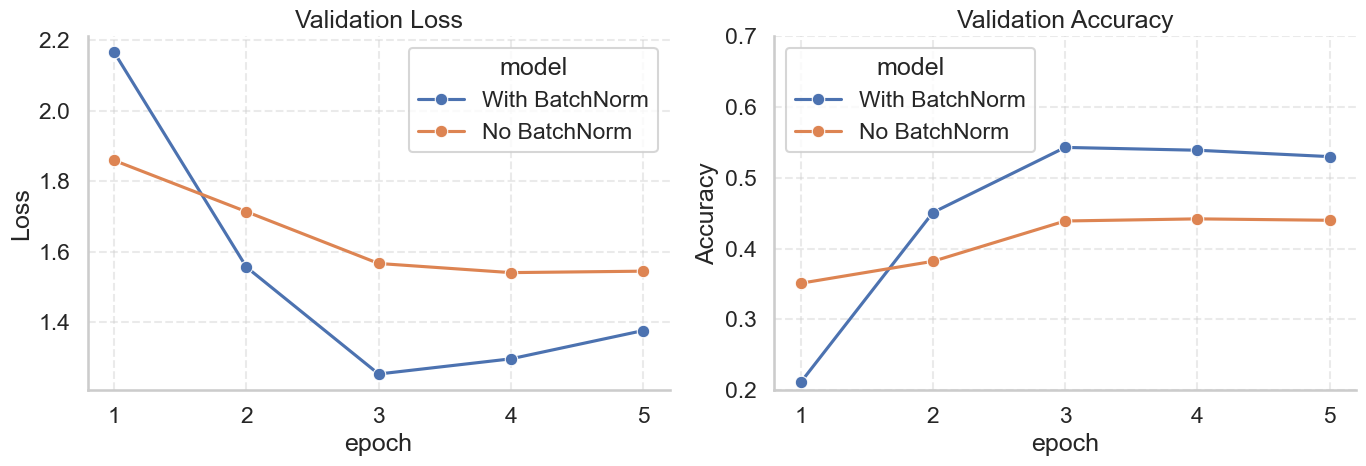

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for metric, ax in zip(['loss', 'accuracy'], axes):
    subset = metrics_df[(metrics_df['metric'] == metric) & (metrics_df['split'] == 'val')]
    sns.lineplot(data=subset, x='epoch', y='value', hue='model', marker='o', ax=ax)
    ax.set_title(f'Validation {metric.title()}')
    ax.set_ylabel(metric.title())
    ax.grid(True, linestyle='--', alpha=0.4)
    if metric == 'accuracy':
        ax.set_ylim(0.2, 0.7)
plt.tight_layout()
plt.show()

## 9. Activation Stability
Comparing per-layer activation statistics reveals how BatchNorm keeps both the mean and spread closer to zero-centered, unit-variance values even as training progresses.

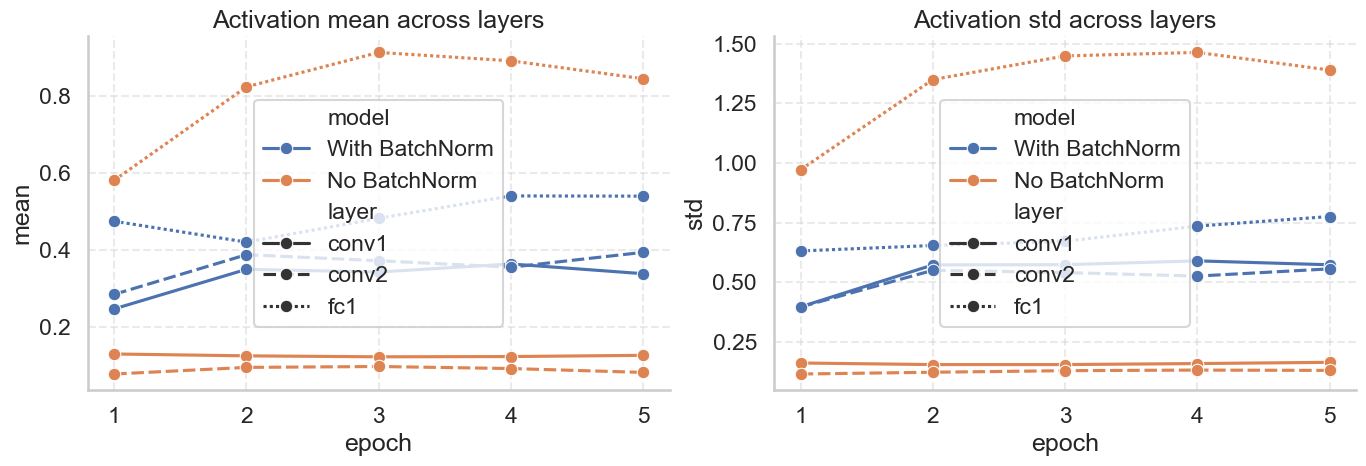

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for metric, ax in zip(['mean', 'std'], axes):
    sns.lineplot(data=activation_df[activation_df['layer'].isin(['conv1', 'conv2', 'fc1'])],
                 x='epoch', y=metric, hue='model', style='layer', marker='o', ax=ax)
    ax.set_title(f'Activation {metric} across layers')
    ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 10. Activation Distributions by Layer
Density plots for the second convolutional block show the raw model’s activations drifting and becoming skewed, while the BatchNorm variant remains tight across epochs.

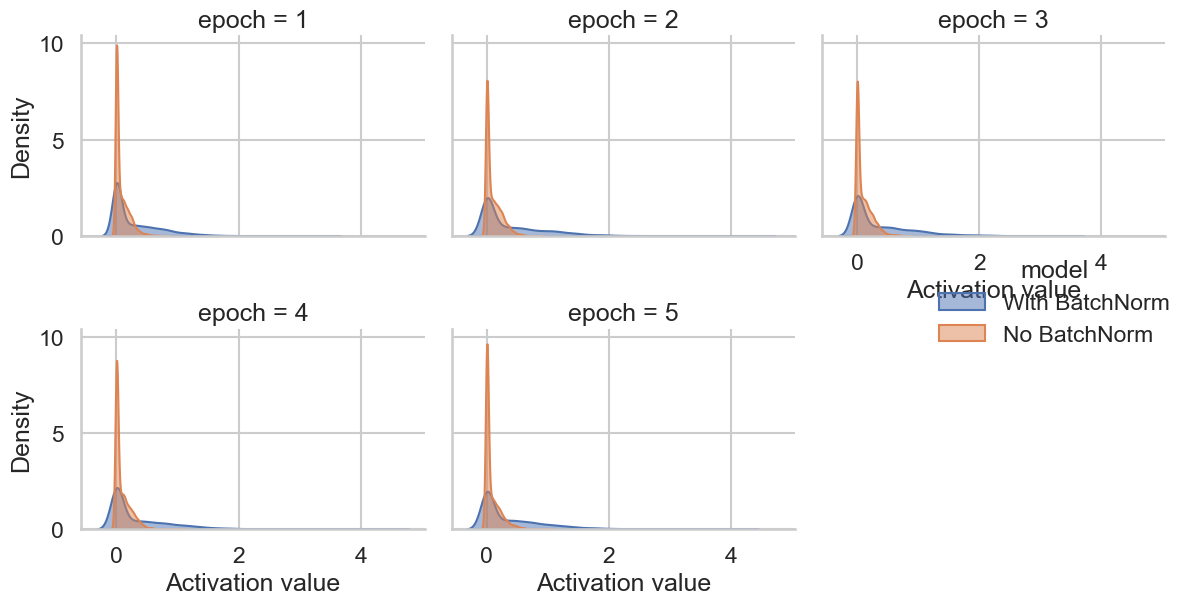

In [10]:
conv2_samples = [rec for rec in activation_samples if rec['layer'] == 'conv2']
frames = []
for rec in conv2_samples:
    frame = pd.DataFrame({
        'value': rec['values'],
        'model': rec['model'],
        'epoch': rec['epoch'],
    })
    frames.append(frame)
conv2_df = pd.concat(frames, ignore_index=True)

conv2_df['epoch'] = conv2_df['epoch'].astype(int)

g = sns.FacetGrid(conv2_df, col='epoch', hue='model', sharex=True, sharey=True, col_wrap=3, height=3.2)
g.map(sns.kdeplot, 'value', fill=True, alpha=0.5)
g.add_legend()
for ax in g.axes.flatten():
    ax.set_xlabel('Activation value')
plt.tight_layout()
plt.show()

## 11. Gradient Norm Heatmaps
Per-layer gradient magnitudes highlight how BatchNorm dampens exploding gradients in deeper layers, keeping training signals balanced.

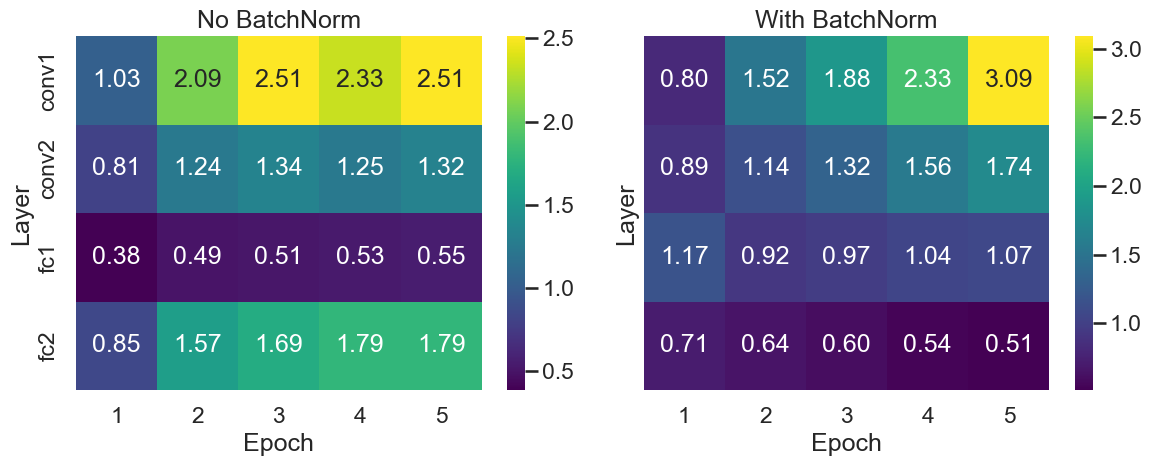

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (model_name, group) in zip(axes, gradient_df.groupby('model')):
    pivot = group.pivot(index='layer', columns='epoch', values='grad_norm').loc[TRACKED_LAYERS]
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='viridis', ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Layer')
plt.tight_layout()
plt.show()

## Key Takeaways
- BatchNorm keeps activation means and variances well-behaved, preventing the drift visible in the plain CNN.
- Gradient norms remain steadier across layers when BatchNorm is present, reducing the risk of exploding or vanishing gradients.
- Faster, smoother validation curves corroborate the stabilization benefits that the activation and gradient visualizations reveal.
- The instrumentation hooks are reusable—swap in deeper networks or different datasets to compare normalization strategies side by side.